In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [8]:
# load the dataset

df=pd.read_csv('loan_approval_dataset.csv')

In [12]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [13]:
# data cleaning

df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [14]:
df.columns = df.columns.str.strip()

In [15]:
# data preprocessing

df = df.drop(columns=['loan_id'])

In [16]:
categorical_cols = ['education', 'self_employed', 'loan_status']
for col in categorical_cols:
    df[col] = df[col].str.strip()

In [17]:
df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

In [18]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [19]:
# Split into training and testing sets (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Scale the numerical features so they have a mean of 0 and variance of 1

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# ANN Architecture

model = Sequential([
    # Input layer + first hidden layer
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),  # Prevents overfitting
    
    # Second hidden layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Output layer (Sigmoid is used for binary classification)
    Dense(1, activation='sigmoid')
])

C:\Users\Thor fin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# Compile and Train

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,  # Uses 20% of training data for validation tracking
    verbose=1
)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7434 - loss: 0.5328 - val_accuracy: 0.9253 - val_loss: 0.3166
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8913 - loss: 0.2890 - val_accuracy: 0.9297 - val_loss: 0.2072
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9063 - loss: 0.2469 - val_accuracy: 0.9356 - val_loss: 0.1823
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9114 - loss: 0.2275 - val_accuracy: 0.9444 - val_loss: 0.1690
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9217 - loss: 0.2080 - val_accuracy: 0.9488 - val_loss: 0.1577
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9202 - loss: 0.2036 - val_accuracy: 0.9546 - val_loss: 0.1518
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9246 - loss: 0.1866 - val_accuracy: 0.9502 - val_loss: 0.1476
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9286 - loss: 0.1831 - val_accuracy: 0.9502 - val_loss

In [24]:
# Evaluation

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 96.25%


In [25]:
# Generate predictions and convert probabilities to binary classes (0 or 1)

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       318
           1       0.97      0.97      0.97       536

    accuracy                           0.96       854
   macro avg       0.96      0.96      0.96       854
weighted avg       0.96      0.96      0.96       854



In [27]:
# plot training

plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

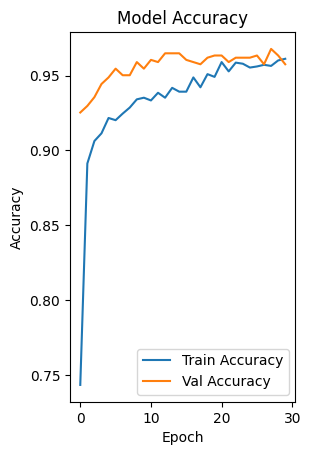

In [28]:
# plot accuracy

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

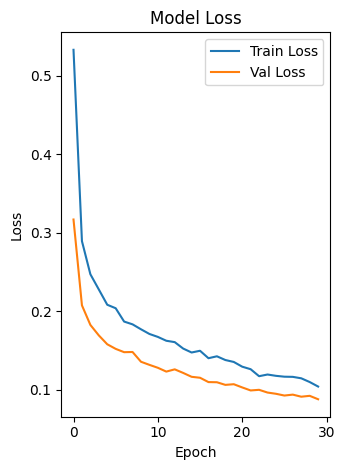

In [29]:
# plot loss

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()